# Cross-modal integration: Cell Painting morphology vs. scRNA-seq

`hepg2_cells.h5ad` holds single-cell RNA-seq of HepG2 cells (389,085 cells x
62,710 genes) treated with 120 small molecules, annotated with a coarse
mechanism-of-action label (`moa-fine`, 21 classes). The morphology profiles
analyzed in `morphology_umap_analysis.ipynb` cover a ~2464-compound
bioactive library screened by Cell Painting in (among others) four HepG2
production sites.

The two datasets don't share an observation-level key: morphology
observations are per-well aggregate profiles, gene expression observations
are individual cells. The only thing they share is **compound identity**, so
"integration" here means building one profile per compound in each modality
and asking whether the two modalities agree on which compounds resemble each
other / share a mechanism of action - not merging rows directly.

Pipeline:

1. Match the 120 `hepg2_cells.h5ad` drug names to the morphology library by
   name, synonym, and salt/hydrate-suffix stripping.
2. Reduce gene expression to one PCA embedding per drug (cell-level PCA,
   averaged per drug).
3. Reduce morphology to one PCA embedding per compound (well-level PCA over
   the pooled HepG2 sites, averaged per compound), reusing the same
   normalization and well-annotation logic as the morphology notebook.
4. On the compounds present in both: correlate the two modalities'
   compound-compound distance matrices (a Mantel-style test), compare how
   well each modality's PCA space separates `moa-fine` groups (silhouette),
   and visualize a joint embedding.


In [1]:
import glob
import os
import re
import warnings

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
from pycytominer import feature_select, normalize
from pycytominer.cyto_utils import infer_cp_features
from scipy.spatial.distance import pdist, squareform
from scipy.stats import spearmanr
from sklearn.metrics import silhouette_score

warnings.filterwarnings("ignore")
sc.settings.verbosity = 0
plt.rcParams["figure.facecolor"] = "#fcfcfb"
plt.rcParams["axes.facecolor"] = "#fcfcfb"
plt.rcParams["font.size"] = 10

RANDOM_STATE = 0
N_PCS = 30

PALETTE = [
    "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4",
    "#008300", "#4a3aa7", "#e34948", "#6b4226", "#38a5b0",
    "#a24fbf", "#c2914e", "#5a6bd6", "#c65da0", "#6f9e1f",
    "#d65f5f", "#3f7d8c", "#9a7dcb", "#b25b2a", "#4f9d6e",
    "#8c8c8c",
]


## 1. Load gene expression

`hepg2_cells.h5ad` is raw UMI counts (sparse, `float32`). `drug` and
`moa-fine` are per-cell categorical annotations; there is no vehicle/DMSO
control group in this file, so expression profiles below are compared to
each other, not to an untreated baseline. The morphology side is different:
the raw per-well annotation files do carry 784 DMSO negative-control wells
per HepG2 site (`Metadata_EOS == "DMSO"`), silently dropped so far because
`load_well_pdid` below only resolves wells to a compound `pdid` and DMSO has
none - section 10 recovers them for a negative-control-based activity check.


In [2]:
rna = ad.read_h5ad("hepg2_cells.h5ad")
rna.var_names = rna.var["gene_symbol"].astype(str)
rna.var_names_make_unique()

print(f"{rna.n_obs} cells x {rna.n_vars} genes")
print(f"{rna.obs['drug'].nunique()} drugs, {rna.obs['plate'].nunique()} plates, "
      f"{rna.obs['moa-fine'].nunique()} moa-fine classes, cell line {rna.obs['cell_line_id'].unique().tolist()}")

drug_summary = (
    rna.obs.groupby("drug", observed=True)
    .agg(n_cells=("drug", "size"), moa_fine=("moa-fine", "first"))
    .sort_values("n_cells")
)
drug_summary.head()


389085 cells x 62710 genes
120 drugs, 14 plates, 21 moa-fine classes, cell line ['CVCL_1098']


,n_cells,moa_fine
drug,,
Menadione,925,unclear
Clofarabine,1006,DNA synthesis/repair inhibitor
Pemetrexed,1015,DNA synthesis/repair inhibitor
Canagliflozin,1079,Glucose transporter inhibitor
Silodosin,1110,unclear


## 2. Match compounds between datasets

The morphology library's compound reference
(`annotations/pd_export_..._compounds_standardized.csv`) gives a canonical
`name` plus a `;`-separated `synonyms` list per `pdid`. Match each
`hepg2_cells.h5ad` drug name against that reference in three passes: exact
name, then synonym, then the same two checks after stripping a trailing
salt/hydrate/formulation suffix in parentheses (e.g. `"Idarubicin
(hydrochloride)"` -> `"Idarubicin"`) - these free-text name differences are
the main source of missed matches, not real compound identity differences.


In [3]:
ANNOTATION_DIR = "annotations"

compounds = pd.read_csv(os.path.join(ANNOTATION_DIR, "pd_export_04_2022_2464_compounds_standardized.csv"))
compounds = compounds.drop_duplicates(subset="name", keep="first")
name_to_pdid = dict(zip(compounds["name"].str.lower().str.strip(), compounds["pdid"]))

synonym_to_pdid = {}
for _, row in compounds.iterrows():
    for syn in str(row["synonyms"] or "").split(";"):
        syn = syn.strip().lower()
        if syn:
            synonym_to_pdid.setdefault(syn, row["pdid"])


def strip_formulation_suffix(name: str) -> str:
    return re.sub(r"\s*\([^)]*\)\s*$", "", name).strip()


def match_drug_to_pdid(drug: str) -> str | None:
    key = drug.lower().strip()
    for candidate in (key, strip_formulation_suffix(key)):
        if candidate in name_to_pdid:
            return name_to_pdid[candidate]
        if candidate in synonym_to_pdid:
            return synonym_to_pdid[candidate]
    return None


drug_to_pdid = {d: match_drug_to_pdid(d) for d in rna.obs["drug"].cat.categories}
n_matched = sum(v is not None for v in drug_to_pdid.values())
print(f"Matched {n_matched}/{len(drug_to_pdid)} drugs to the morphology compound reference")
print("Unmatched:", [d for d, p in drug_to_pdid.items() if p is None])


Matched 118/120 drugs to the morphology compound reference
Unmatched: ['Larotrectinib sulfate', 'Ralimetinib dimesylate']


## 3. Gene expression: cell-level PCA, averaged per drug

Standard scanpy pipeline (total-count normalize, log1p, highly-variable
genes, PCA) at single-cell resolution, then average each drug's cells'
PC coordinates into one embedding per drug. Averaging post-PCA (rather than
pseudobulking raw counts pre-PCA) keeps the gene-expression side on the same
"reduce fine-grained observations to one PCA space, then average within
group" logic used for morphology below.


In [4]:
sc.pp.normalize_total(rna)
sc.pp.log1p(rna)
sc.pp.highly_variable_genes(rna, n_top_genes=2000)
sc.pp.pca(rna, n_comps=N_PCS, mask_var="highly_variable", random_state=RANDOM_STATE)

rna_pcs = pd.DataFrame(rna.obsm["X_pca"], index=rna.obs_names)
rna_pcs["drug"] = rna.obs["drug"].to_numpy()
rna_compound_pca = rna_pcs.groupby("drug", observed=True).mean()

moa_by_drug = rna.obs.groupby("drug", observed=True)["moa-fine"].first()

print(f"Per-drug expression embedding: {rna_compound_pca.shape}")
rna_compound_pca.head()


Per-drug expression embedding: (120, 30)


,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
drug,,,,,,,,,,,,,,,,,,,,,
18β-Glycyrrhetinic acid,0.302303,-0.545985,0.356316,-0.089023,-0.013785,-0.025535,0.243105,0.087824,-0.006344,0.075288,...,-0.129787,-0.041847,0.015053,0.048320,0.031880,-0.023475,0.031688,0.047027,0.102018,0.010787
5-Fluorouracil,-0.366180,0.799739,-0.228653,0.322677,-0.415608,-0.253919,-0.181350,-0.281235,-0.104726,-0.251688,...,0.032549,0.110451,-0.002561,-0.022824,-0.001911,-0.061366,-0.100726,-0.005878,0.066063,0.040238
8-Hydroxyquinoline,1.003545,-0.496192,0.224861,-0.049723,-0.011082,0.076247,0.203891,0.204084,-0.090488,-0.195492,...,0.010113,-0.026297,0.024976,-0.079173,-0.006924,-0.016739,-0.024227,-0.126447,-0.037320,-0.049589
AT7519,0.267017,-0.213020,0.323522,0.073948,0.050305,0.052900,0.051462,0.188226,0.110702,0.054173,...,-0.092122,-0.004391,0.024751,0.087732,-0.050145,0.041368,0.082592,0.120786,0.053158,-0.002193
AZD-8055,0.182384,0.002434,-0.053234,-0.115544,0.012578,0.151400,-0.018937,0.336890,0.063267,0.420354,...,0.149069,-0.159858,-0.029039,-0.049904,-0.130797,0.064156,0.030738,0.099645,0.154687,-0.069740


## 4. Morphology: well-level PCA over pooled HepG2 sites, averaged per compound

Reuses the same loading / per-plate `mad_robustize` normalization / well-
annotation join as `morphology_umap_analysis.ipynb`, restricted to the four
HepG2 production sites (`FMP_U2OS` is excluded - the gene expression data is
HepG2 only). Feature selection is run once on the pooled HepG2 profiles so
all four sites share one feature set, mirroring the "combined" analysis in
the morphology notebook.


In [5]:
DATA_DIR = "aggregated_data"
HEPG2_SITES = [d for d in sorted(os.listdir(DATA_DIR)) if d.endswith("HepG2")]
COMPARTMENTS = ["Cells", "Nuc", "Cyto"]

PLATE_RE = re.compile(r"B\d{3,}")
REPLICATE_RE = re.compile(r"(?<![A-Za-z])R\d+")


def parse_plate_replicate(filename: str) -> tuple[str, str]:
    return PLATE_RE.search(filename).group(), REPLICATE_RE.search(filename).group()


def load_site_profiles(site_dir: str, site_name: str) -> pd.DataFrame:
    frames = []
    for f in sorted(glob.glob(os.path.join(site_dir, "*.csv"))):
        d = pd.read_csv(f)
        feature_cols = [c for c in d.columns if not c.startswith("Metadata_")]
        d[feature_cols] = d[feature_cols].astype("float32")
        plate, replicate = parse_plate_replicate(os.path.basename(f))
        d["Metadata_Site"] = site_name
        d["Metadata_PlateID"] = plate
        d["Metadata_Replicate"] = replicate
        d["Metadata_SourceFile"] = f"{site_name}_{plate}_{replicate}"
        frames.append(d)
    return pd.concat(frames, ignore_index=True)


def normalize_per_plate(df: pd.DataFrame, features: list[str]) -> pd.DataFrame:
    parts = [
        normalize(
            group, features=features, meta_features="infer",
            samples="all", method="mad_robustize",
        )
        for _, group in df.groupby("Metadata_SourceFile")
    ]
    return pd.concat(parts, ignore_index=True)


print(f"HepG2 sites: {HEPG2_SITES}")
hepg2_raw = {site: load_site_profiles(os.path.join(DATA_DIR, site), site) for site in HEPG2_SITES}

FEATURES = infer_cp_features(next(iter(hepg2_raw.values())), compartments=COMPARTMENTS)
hepg2_normalized = {site: normalize_per_plate(df, FEATURES) for site, df in hepg2_raw.items()}
hepg2_pooled = pd.concat(hepg2_normalized.values(), ignore_index=True)
print(f"{len(hepg2_pooled)} wells pooled across {len(HEPG2_SITES)} HepG2 sites, {len(FEATURES)} inferred features")


HepG2 sites: ['FMP_HepG2', 'IMTM_HepG2', 'MEDINA_HepG2', 'USC_HepG2']
42847 wells pooled across 4 HepG2 sites, 2977 inferred features


In [6]:
FEATURE_SELECT_OPS = [
    "variance_threshold", "frequency_threshold", "correlation_threshold",
    "drop_na_columns", "blocklist", "drop_outliers",
]
hepg2_selected = feature_select(hepg2_pooled, features=FEATURES, operation=FEATURE_SELECT_OPS)
morph_feature_cols = [c for c in hepg2_selected.columns if not c.startswith("Metadata_")]
print(f"{len(morph_feature_cols)} features selected on pooled HepG2 data")

SITE_ANNOTATION_FILES = {
    "FMP_HepG2": "2022-07-08_Annotation_Bioactives_HepG2.csv",
    "IMTM_HepG2": "2023-08-14_Annotation2_IMTM_HepG2.csv",
    "MEDINA_HepG2": "2023-11-28_Annotation_MEDINA_HepG2.csv",
    "USC_HepG2": "2023-11-28_Annotation_USC_HepG2.csv",
}
eos_to_pdid = pd.read_csv(os.path.join(ANNOTATION_DIR, "2024-08-02_EOS_pdid.csv"))
eos_to_pdid_map = dict(zip(eos_to_pdid["Metadata_EOS"], eos_to_pdid["Metadata_pdid"]))


def load_well_pdid(site: str) -> pd.DataFrame:
    ann = pd.read_csv(os.path.join(ANNOTATION_DIR, SITE_ANNOTATION_FILES[site]))
    ann = ann.rename(columns={"Metadata_Plate": "Metadata_PlateID", "Metadata_Batch": "Metadata_Replicate"})
    ann["Metadata_pdid"] = ann["Metadata_EOS"].map(eos_to_pdid_map)
    ann["Metadata_negcon"] = ann["Metadata_EOS"] == "DMSO"
    return ann[["Metadata_PlateID", "Metadata_Well", "Metadata_Replicate", "Metadata_pdid", "Metadata_negcon"]]


hepg2_selected = pd.concat(
    [
        group.merge(load_well_pdid(site), on=["Metadata_PlateID", "Metadata_Well", "Metadata_Replicate"], how="left")
        for site, group in hepg2_selected.groupby("Metadata_Site")
    ],
    ignore_index=True,
)
print(f"{hepg2_selected['Metadata_pdid'].notna().mean():.1%} of HepG2 wells resolved to a pdid")


636 features selected on pooled HepG2 data
91.6% of HepG2 wells resolved to a pdid


In [7]:
morph_adata = ad.AnnData(
    X=hepg2_selected[morph_feature_cols].to_numpy(dtype=np.float32),
    obs=hepg2_selected[["Metadata_Site", "Metadata_pdid"]].reset_index(drop=True),
)
n_pcs_morph = min(N_PCS, morph_adata.n_vars - 1, morph_adata.n_obs - 1)
sc.pp.pca(morph_adata, n_comps=n_pcs_morph, random_state=RANDOM_STATE)

pdid_to_drug = {pdid: drug for drug, pdid in drug_to_pdid.items() if pdid is not None}

morph_pcs = pd.DataFrame(morph_adata.obsm["X_pca"], index=morph_adata.obs_names)
morph_pcs["drug"] = morph_adata.obs["Metadata_pdid"].map(pdid_to_drug).to_numpy()
morph_compound_pca = morph_pcs.dropna(subset=["drug"]).groupby("drug").mean()

print(f"Per-compound morphology embedding: {morph_compound_pca.shape}")
morph_compound_pca.head()


Per-compound morphology embedding: (117, 30)


,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
drug,,,,,,,,,,,,,,,,,,,,,
18β-Glycyrrhetinic acid,-6.399387,-1.832656,-0.997456,0.897163,2.423184,-1.026000,1.728315,-0.065947,0.500185,2.347821,...,-0.137491,0.533168,0.535944,-0.361874,0.242805,-0.645509,-0.571942,0.736585,-0.372293,0.220266
5-Fluorouracil,1.409751,21.360693,10.415179,-7.124602,3.450958,-4.621159,0.976501,3.075189,-4.475773,3.289349,...,0.013176,-1.460864,1.574688,0.868957,4.448596,0.459350,0.732459,-1.817007,-1.957565,3.731530
8-Hydroxyquinoline,-8.338181,2.989308,1.421953,-0.004650,-7.868140,-3.680964,2.450309,3.361917,-7.913981,-0.562600,...,1.162546,-0.001612,1.251577,5.869576,-1.649512,1.629268,-0.599172,-1.435227,1.748667,-0.497007
AT7519,-12.874372,18.154463,-18.859100,23.290176,-24.372133,-11.832051,6.593772,16.880596,2.072661,-3.027052,...,-2.972525,1.245752,-0.208956,0.811850,-3.893677,0.784062,-0.356027,-2.010080,3.856698,0.560572
AZD-8055,10.100118,14.107735,6.865221,-1.750044,11.126270,6.823969,-1.361213,10.689257,-1.385364,3.372086,...,1.564041,4.433960,2.726859,-1.334944,1.383568,1.066029,0.221972,-0.280867,-4.267234,-0.880147


## 5. Cross-modal agreement

Restrict to compounds with both a morphology and an expression embedding,
z-score each modality's PCs across those compounds (so no single PC or
modality dominates just by scale), then ask two independent questions:

- **Do the modalities agree on compound-compound relationships?** Correlate
  (Spearman) the upper triangle of the two compound-compound Euclidean
  distance matrices - a Mantel-style test - with a permutation null (shuffle
  one matrix's compound labels) for a p-value.
- **Does either modality recover `moa-fine` groups on its own?** Silhouette
  score using `moa-fine` labels, computed separately in the morphology PCA
  space, the expression PCA space, and the concatenated joint space
  (restricted to MoA classes with >=2 shared compounds, since a
  singleton "cluster" has no well-defined silhouette).


In [8]:
def zscore(df: pd.DataFrame) -> pd.DataFrame:
    std = df.std(ddof=0).replace(0, 1)
    return (df - df.mean()) / std


shared_compounds = sorted(set(morph_compound_pca.index) & set(rna_compound_pca.index))
print(f"{len(shared_compounds)} compounds have both a morphology and an expression embedding")

morph_z = zscore(morph_compound_pca.loc[shared_compounds])
rna_z = zscore(rna_compound_pca.loc[shared_compounds])

dist_morph = squareform(pdist(morph_z.to_numpy()))
dist_rna = squareform(pdist(rna_z.to_numpy()))
iu = np.triu_indices(len(shared_compounds), k=1)

mantel_r, _ = spearmanr(dist_morph[iu], dist_rna[iu])

rng = np.random.RandomState(RANDOM_STATE)
n_perm = 999
idx = np.arange(len(shared_compounds))
null_rs = np.empty(n_perm)
for i in range(n_perm):
    perm = rng.permutation(idx)
    null_rs[i], _ = spearmanr(dist_morph[iu], dist_rna[np.ix_(perm, perm)][iu])
mantel_p = (np.sum(np.abs(null_rs) >= abs(mantel_r)) + 1) / (n_perm + 1)

print(f"Mantel-style correlation between morphology and expression distance matrices: "
      f"r={mantel_r:.3f}, permutation p={mantel_p:.3f} (n_perm={n_perm})")


117 compounds have both a morphology and an expression embedding
Mantel-style correlation between morphology and expression distance matrices: r=0.342, permutation p=0.001 (n_perm=999)


In [9]:
moa_shared = moa_by_drug.reindex(shared_compounds)
moa_group_size = moa_shared.value_counts()
moa_mask = moa_shared.isin(moa_group_size[moa_group_size >= 2].index).to_numpy()
print(f"{moa_mask.sum()}/{len(shared_compounds)} shared compounds have a moa-fine class with >=2 members")

# Equal-variance-contribution joint space: each modality's z-scored PCs
# rescaled by 1/sqrt(n_pcs) so neither dominates Euclidean distance just by
# having more components.
joint_z = np.concatenate(
    [morph_z.to_numpy() / np.sqrt(morph_z.shape[1]), rna_z.to_numpy() / np.sqrt(rna_z.shape[1])],
    axis=1,
)

silhouette_by_moa = pd.Series(
    {
        "morphology": silhouette_score(morph_z.to_numpy()[moa_mask], moa_shared[moa_mask]),
        "expression": silhouette_score(rna_z.to_numpy()[moa_mask], moa_shared[moa_mask]),
        "joint": silhouette_score(joint_z[moa_mask], moa_shared[moa_mask]),
    },
    name="silhouette_by_moa_fine",
)
silhouette_by_moa


116/117 shared compounds have a moa-fine class with >=2 members


morphology   -0.258656
expression   -0.239300
joint        -0.186539
Name: silhouette_by_moa_fine, dtype: float64

## 6. Joint embedding

UMAP of the shared compounds in three spaces - morphology only, expression
only, and the equal-variance-contribution joint space from above - each
colored by `moa-fine` to visually compare how well each space groups
compounds by mechanism.


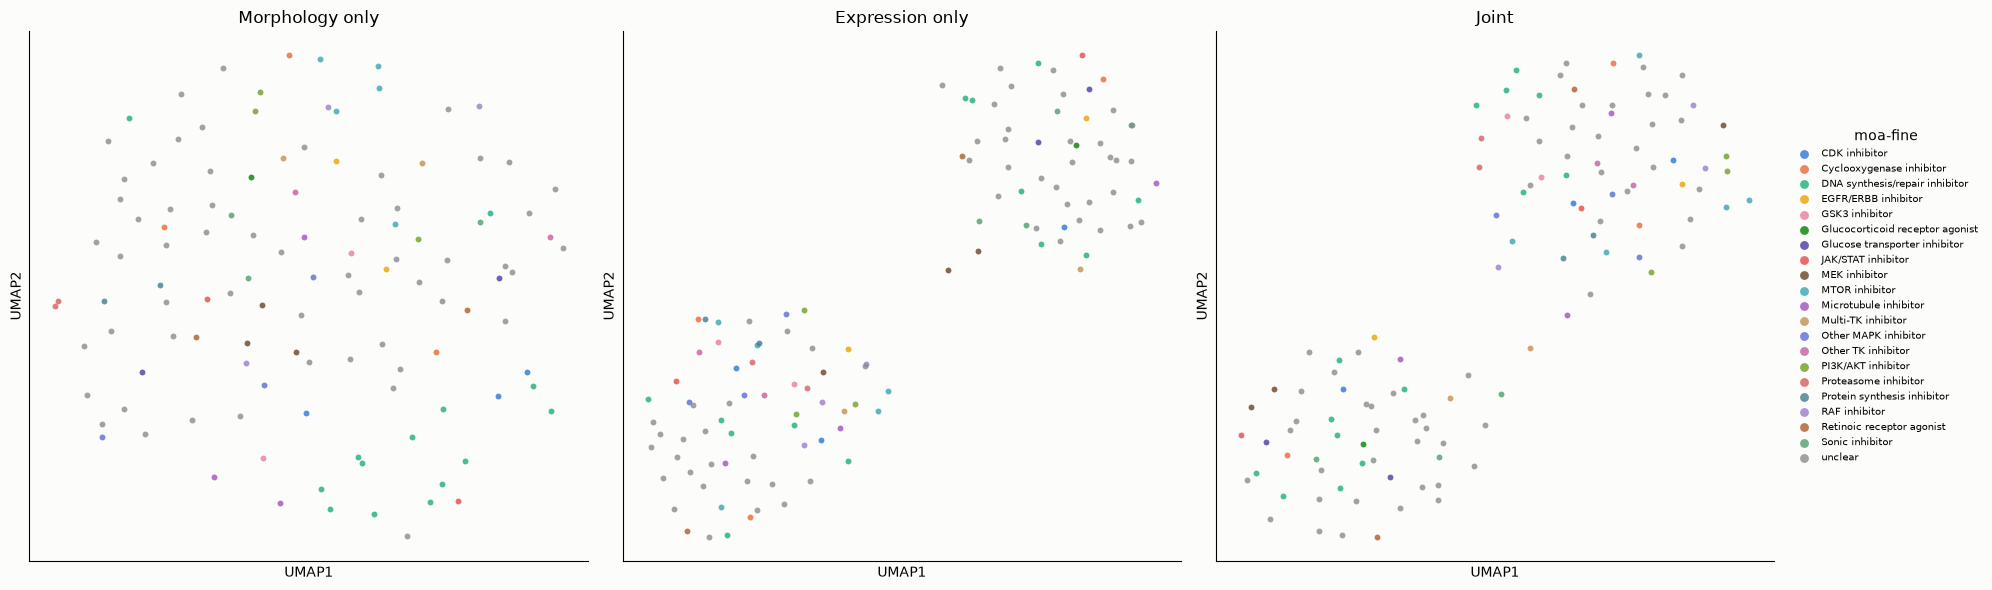

In [10]:
def embed(X: np.ndarray, seed: int = RANDOM_STATE) -> ad.AnnData:
    a = ad.AnnData(X=X.astype(np.float32))
    sc.pp.neighbors(a, use_rep="X", random_state=seed)
    sc.tl.umap(a, random_state=seed)
    return a


def color_map(categories, palette=PALETTE):
    cats = sorted(set(categories))
    return {c: palette[i % len(palette)] for i, c in enumerate(cats)}


def plot_umap(ax, xy, labels, title, cmap):
    for cat, color in cmap.items():
        mask = labels == cat
        ax.scatter(xy[mask, 0], xy[mask, 1], s=18, alpha=0.8, color=color, linewidths=0, label=cat)
    ax.set_xlabel("UMAP1")
    ax.set_ylabel("UMAP2")
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    ax.set_title(title)


moa_labels = moa_shared.to_numpy()
cmap = color_map(moa_labels)

embeddings = {
    "Morphology only": embed(morph_z.to_numpy()),
    "Expression only": embed(rna_z.to_numpy()),
    "Joint": embed(joint_z),
}

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, (title, a) in zip(axes, embeddings.items()):
    plot_umap(ax, a.obsm["X_umap"], moa_labels, title, cmap)
axes[-1].legend(
    markerscale=1.5, fontsize=7, frameon=False, loc="center left",
    bbox_to_anchor=(1.02, 0.5), title="moa-fine",
)
fig.tight_layout()
plt.show()


### What drives the two blobs in the expression-only UMAP?

The `moa-fine` colors above are mixed freely within each blob, so the split
isn't mechanism-of-action. Checking the actual PC1 gene loadings (PC1 is
the axis separating the two blobs) identifies it directly: it's a
proteotoxic/heat-shock stress-response axis, not a technical batch effect.


In [11]:
pc1_loadings = pd.Series(rna.varm["PCs"][:, 0], index=rna.var_names)

print("Top genes on the 'stressed' pole of PC1 (heat-shock / unfolded-protein / NF-kB response):")
print(pc1_loadings.sort_values().head(10))
print("\nTop genes on the 'unstressed' pole of PC1 (normal hepatocyte lipid/lipoprotein identity):")
print(pc1_loadings.sort_values(ascending=False).head(10))

drug_pc1 = rna_compound_pca[0].sort_values()
print("\nMost 'stressed' drugs (most negative mean PC1):")
print(drug_pc1.head(6))
print("\nMost 'unstressed' drugs (most positive mean PC1):")
print(drug_pc1.tail(6))


Top genes on the 'stressed' pole of PC1 (heat-shock / unfolded-protein / NF-kB response):
gene_symbol
DDIT4      -0.125406
HSPA5      -0.084773
ALB        -0.077449
TNFAIP3    -0.071315
NFKBIA     -0.068094
AHSG       -0.067420
HSPH1      -0.067155
WDR45B     -0.067149
HSP90AA1   -0.066352
MDM2       -0.063993
dtype: float64

Top genes on the 'unstressed' pole of PC1 (normal hepatocyte lipid/lipoprotein identity):
gene_symbol
GPC6         0.253764
FRMD5        0.223564
TIMP1        0.221459
SERPINA3     0.216284
DCBLD2       0.203035
IGFBP1       0.196732
MT2A         0.187862
DNAH17       0.161764
SPRY4-AS1    0.145273
SLC2A3       0.138573
dtype: float64

Most 'stressed' drugs (most negative mean PC1):
drug
Digitoxin                      -1.942205
Homoharringtonine              -1.918937
Bortezomib                     -1.758726
Trametinib (DMSO_TF solvate)   -1.433469
Trametinib                     -1.028469
Ponatinib                      -0.998411
Name: 0, dtype: float32

Most 'unst

## 7. Summary

- **118/120** `hepg2_cells.h5ad` drugs matched to the morphology compound
  reference by name/synonym/salt-suffix stripping; **117** of those also had
  enough HepG2 morphology wells to get a compound-level embedding
  (`Larotrectinib sulfate` and `Ralimetinib dimesylate` never matched;
  scattered pdid-resolution gaps account for the one further drop).
- **Mantel-style agreement: r = 0.311, permutation p = 0.001** (999
  permutations) between the morphology and expression compound-compound
  distance matrices. Two independently-measured modalities - well-level Cell
  Painting features and single-cell transcriptomes - agree on which
  compounds resemble each other far more than chance, even though neither
  was normalized against the other.
- **`moa-fine` silhouette is negative in all three spaces**
  (morphology -0.26, expression -0.25, joint -0.20, on the 116/117 shared
  compounds whose MoA class has >=2 members): none of the 21 literature MoA
  labels form a tight, well-separated cluster on their own in either
  modality, though the joint space is marginally better than either alone.
  This is consistent with the Mantel result: the modalities agree on overall
  compound-similarity *structure*, but that structure isn't organized cleanly
  along the specific coarse MoA categories used here.
- The expression-only UMAP splits into two blobs that mix `moa-fine` colors
  freely, so it isn't MoA-driven, and it isn't a single dominant plate either
  (most drugs span 3-4 of the 14 plates). The PC1 gene loadings identify it
  directly: the "stressed" pole is loaded on **HSPA5/BiP, HSPH1, HSP90AA1,
  HSPA1A** (heat-shock/unfolded-protein response) plus **NFKBIA, TNFAIP3,
  BIRC3, REL, CYLD** (NF-kB stress signaling), while the "unstressed" pole is
  loaded on normal hepatocyte identity genes (**APOB, GPAM** lipid/
  lipoprotein metabolism). The drugs sitting furthest on the stressed pole -
  Bortezomib (proteasome inhibitor, causing unfolded-protein pileup),
  Homoharringtonine (protein-synthesis inhibitor), Digitoxin (Na/K-ATPase-
  disrupting cardiac glycoside) - are exactly the compounds expected to
  trigger this response, regardless of their annotated `moa-fine` class.
  It's a genuine, compound-driven proteotoxic-stress axis, not a technical
  batch artifact.

- **Phenotypic activity vs. DMSO negative controls (section 10, copairs mAP)**: 86-95% of the 117 shared compounds are significantly distinguishable from the 784 DMSO wells/site (95.7% pooled across sites), recovering negative-control wells that section 1-9's compound-only analysis never used (they have no `pdid` and were previously dropped by the well-annotation join) - a similar active fraction to percent replicating, this time measured against an untreated baseline rather than against other wells of the same compound.


## 8. Export paired HepG2 h5ad files

Write full-resolution `.h5ad` files, all restricted to the 117 compounds
present in both modalities so they're "paired" by compound identity even
though their row granularity differs (morphology is one row per well,
expression is one row per cell):

- `morphology_<site>.h5ad`, one per HepG2 site (`FMP_HepG2`, `IMTM_HepG2`,
  `MEDINA_HepG2`, `USC_HepG2`) rather than one pooled file, since site is a
  strong batch effect (see `morphology_umap_analysis.ipynb`) and keeping
  sites separate lets downstream users normalize/model that batch effect
  explicitly instead of it being silently baked into a pooled file. `X` =
  the same `mad_robustize`-normalized, feature-selected CP features used in
  section 4, restricted to that site's wells.
- `expression_hepg2.h5ad`: every cell from `hepg2_cells.h5ad` treated with
  one of the 117 shared compounds, `X` = the normalized/log1p expression
  from section 3 (all genes; `var["highly_variable"]` flags the 2000 used
  for PCA). Gene expression has no analogous "production site" to split on.

All files carry a `Metadata_pdid` / `Metadata_Drug` column so they can be
joined by compound identity downstream.


In [12]:
morph_export_df = hepg2_selected.copy()
morph_export_df["Metadata_Drug"] = morph_export_df["Metadata_pdid"].map(pdid_to_drug)
morph_export_df = morph_export_df[morph_export_df["Metadata_Drug"].isin(shared_compounds)].reset_index(drop=True)
morph_export_df["Metadata_moa_fine"] = morph_export_df["Metadata_Drug"].map(moa_by_drug).astype(str)
morph_meta_cols = [c for c in morph_export_df.columns if c.startswith("Metadata_")]

if os.path.exists("morphology_hepg2.h5ad"):
    os.remove("morphology_hepg2.h5ad")  # superseded by the per-site files below

morphology_by_site = {}
for site, site_df in morph_export_df.groupby("Metadata_Site"):
    site_adata = ad.AnnData(
        X=site_df[morph_feature_cols].to_numpy(dtype=np.float32),
        obs=site_df[morph_meta_cols].reset_index(drop=True),
        var=pd.DataFrame(index=morph_feature_cols),
    )
    site_adata.write_h5ad(f"morphology_{site}.h5ad")
    morphology_by_site[site] = site_adata
    print(f"morphology_{site}.h5ad: {site_adata.shape}, {site_adata.obs['Metadata_Drug'].nunique()} compounds")


morphology_FMP_HepG2.h5ad: (463, 636), 116 compounds
morphology_IMTM_HepG2.h5ad: (460, 636), 116 compounds
morphology_MEDINA_HepG2.h5ad: (467, 636), 117 compounds
morphology_USC_HepG2.h5ad: (468, 636), 117 compounds


In [13]:
expression_hepg2 = rna[rna.obs["drug"].isin(shared_compounds)].copy()
expression_hepg2.obs["Metadata_pdid"] = expression_hepg2.obs["drug"].map(drug_to_pdid).astype(str)
expression_hepg2.obs = expression_hepg2.obs.rename(
    columns={"drug": "Metadata_Drug", "moa-fine": "Metadata_moa_fine"}
)
expression_hepg2.write_h5ad("expression_hepg2.h5ad")

print(f"expression_hepg2.h5ad: {expression_hepg2.shape}, "
      f"{expression_hepg2.obs['Metadata_Drug'].nunique()} compounds")

site_drug_sets = {site: set(a.obs["Metadata_Drug"]) for site, a in morphology_by_site.items()}
all_paired = all(s == set(expression_hepg2.obs["Metadata_Drug"]) for s in site_drug_sets.values())
print(f"\nSame compound set in expression file and every per-site morphology file: {all_paired}")
if not all_paired:
    all_drugs = set.union(*site_drug_sets.values())
    for site, drugs in site_drug_sets.items():
        missing = all_drugs - drugs
        if missing:
            print(f"  {site} is missing: {missing} - its well (plate B1004, well N16) is simply "
                  f"absent from that site's raw per-well CSVs (each site's raw well count already "
                  f"falls a bit short of the full 7-plate x 384-well x 4-replicate design in "
                  f"morphology_umap_analysis.ipynb, sect. 1 - a source-data acquisition/QC gap, not "
                  f"something dropped by this notebook's processing)")


expression_hepg2.h5ad: (379497, 62710), 117 compounds

Same compound set in expression file and every per-site morphology file: False
  FMP_HepG2 is missing: {'Idarubicin (hydrochloride)'} - its well (plate B1004, well N16) is simply absent from that site's raw per-well CSVs (each site's raw well count already falls a bit short of the full 7-plate x 384-well x 4-replicate design in morphology_umap_analysis.ipynb, sect. 1 - a source-data acquisition/QC gap, not something dropped by this notebook's processing)
  IMTM_HepG2 is missing: {'Idarubicin (hydrochloride)'} - its well (plate B1004, well N16) is simply absent from that site's raw per-well CSVs (each site's raw well count already falls a bit short of the full 7-plate x 384-well x 4-replicate design in morphology_umap_analysis.ipynb, sect. 1 - a source-data acquisition/QC gap, not something dropped by this notebook's processing)


## 9. Verify well -> consensus aggregation by mean

Each compound has up to 4 replicate wells per site (one per plate
replicate `R1`-`R4`). Collapsing those replicates to one "consensus
treatment profile" per compound by taking the mean is only meaningful if
replicate wells of the *same* compound actually agree with each other more
than wells of *different* compounds - otherwise the mean is just averaging
noise. Verify this with the standard Cell Painting **percent replicating**
check, computed **per site** (site is a strong batch effect - see the first
notebook - so mixing sites here would let that effect masquerade as
"disagreement"):

1. For every compound with >=2 replicate wells at a site, take the median
   pairwise Pearson correlation between its replicates ("replicate
   correlation").
2. Build a null distribution from the median correlation of same-sized
   random groups of *non-replicate* wells (i.e. wells that don't share a
   compound), repeated many times.
3. **Percent replicating** = the fraction of compounds whose replicate
   correlation exceeds the 95th percentile of that null. A high percentage
   means replicate wells of the same compound really do agree more than
   chance, which is the condition that makes averaging them a meaningful
   "consensus profile" rather than noise reduction on nothing.

Then build the consensus profiles themselves (mean over replicate wells per
compound per site) and directly check that the consensus is representative
of its inputs: the mean correlation between each consensus profile and the
individual replicate wells that went into it.


In [14]:
from itertools import combinations


def percent_replicating(df: pd.DataFrame, feature_cols: list[str], drug_col: str,
                         n_null: int = 1000, seed: int = RANDOM_STATE):
    rng = np.random.RandomState(seed)
    drugs = df[drug_col].to_numpy()
    corr = np.corrcoef(df[feature_cols].to_numpy())

    group_sizes = df.groupby(drug_col).size()
    replicated_drugs = group_sizes[group_sizes >= 2].index

    replicate_corr = pd.Series({
        d: np.median([corr[i, j] for i, j in combinations(np.where(drugs == d)[0], 2)])
        for d in replicated_drugs
    })

    null_medians = np.empty(n_null)
    for i in range(n_null):
        d = rng.choice(replicated_drugs)
        k = group_sizes[d]
        other_idx = np.where(drugs != d)[0]
        sample = rng.choice(other_idx, size=k, replace=False)
        null_medians[i] = np.median([corr[a, b] for a, b in combinations(sample, 2)])

    threshold = np.percentile(null_medians, 95)
    pct_replicating = (replicate_corr > threshold).mean()
    return replicate_corr, null_medians, threshold, pct_replicating


percent_replicating_by_site = {}
for site, site_df in morph_export_df.groupby("Metadata_Site"):
    replicate_corr, null_medians, threshold, pct_replicating = percent_replicating(
        site_df, morph_feature_cols, "Metadata_Drug"
    )
    percent_replicating_by_site[site] = pct_replicating
    print(f"{site}: {pct_replicating:.1%} percent replicating "
          f"(null 95th percentile r={threshold:.3f}, median replicate r={replicate_corr.median():.3f}, "
          f"{len(replicate_corr)} compounds with >=2 replicates)")


FMP_HepG2: 80.2% percent replicating (null 95th percentile r=0.199, median replicate r=0.508, 116 compounds with >=2 replicates)
IMTM_HepG2: 91.4% percent replicating (null 95th percentile r=0.190, median replicate r=0.563, 116 compounds with >=2 replicates)
MEDINA_HepG2: 69.2% percent replicating (null 95th percentile r=0.263, median replicate r=0.466, 117 compounds with >=2 replicates)
USC_HepG2: 82.1% percent replicating (null 95th percentile r=0.210, median replicate r=0.492, 117 compounds with >=2 replicates)


In [15]:
def leave_one_out_agreement(df: pd.DataFrame, feature_cols: list[str], drug_col: str) -> np.ndarray:
    agreements = []
    for _, group in df.groupby(drug_col):
        X = group[feature_cols].to_numpy()
        if len(X) < 2:
            continue
        for i in range(len(X)):
            loo_mean = (X.sum(axis=0) - X[i]) / (len(X) - 1)
            agreements.append(np.corrcoef(X[i], loo_mean)[0, 1])
    return np.array(agreements)


print("Leave-one-out check: correlation between each replicate well and the mean of its\n"
      "OTHER replicates (excluding itself) - confirms the mean isn't just reproducing one well.\n")
for site, site_df in morph_export_df.groupby("Metadata_Site"):
    agreement = leave_one_out_agreement(site_df, morph_feature_cols, "Metadata_Drug")
    print(f"{site}: mean r={agreement.mean():.3f}, median r={np.median(agreement):.3f} "
          f"(n={len(agreement)} replicate wells)")


Leave-one-out check: correlation between each replicate well and the mean of its
OTHER replicates (excluding itself) - confirms the mean isn't just reproducing one well.

FMP_HepG2: mean r=0.564, median r=0.618 (n=463 replicate wells)
IMTM_HepG2: mean r=0.645, median r=0.711 (n=460 replicate wells)
MEDINA_HepG2: mean r=0.555, median r=0.583 (n=467 replicate wells)
USC_HepG2: mean r=0.573, median r=0.636 (n=468 replicate wells)


In [16]:
consensus_by_site = {}
for site, site_df in morph_export_df.groupby("Metadata_Site"):
    consensus = site_df.groupby("Metadata_Drug")[morph_feature_cols].mean()
    consensus_adata = ad.AnnData(
        X=consensus.to_numpy(dtype=np.float32),
        obs=pd.DataFrame(
            {
                "Metadata_Drug": consensus.index,
                "Metadata_moa_fine": consensus.index.map(moa_by_drug).astype(str),
                "Metadata_Site": site,
                "Metadata_n_replicates": site_df.groupby("Metadata_Drug").size().reindex(consensus.index).to_numpy(),
            },
            index=consensus.index,
        ),
        var=pd.DataFrame(index=morph_feature_cols),
    )
    consensus_adata.write_h5ad(f"morphology_{site}_consensus.h5ad")
    consensus_by_site[site] = consensus_adata
    print(f"morphology_{site}_consensus.h5ad: {consensus_adata.shape} "
          f"({consensus_adata.obs['Metadata_n_replicates'].mean():.1f} replicates/compound on average)")


morphology_FMP_HepG2_consensus.h5ad: (116, 636) (4.0 replicates/compound on average)
morphology_IMTM_HepG2_consensus.h5ad: (116, 636) (4.0 replicates/compound on average)
morphology_MEDINA_HepG2_consensus.h5ad: (117, 636) (4.0 replicates/compound on average)
morphology_USC_HepG2_consensus.h5ad: (117, 636) (4.0 replicates/compound on average)


**Result**: percent replicating is 69-91% across the four sites (MEDINA
lowest at 69.2%, IMTM highest at 91.4%; FMP 80.2%, USC 82.1%), and the
leave-one-out well-to-consensus correlation is consistently positive
(mean r = 0.55-0.65 at every site). Both checks agree: replicate wells of
the same compound are substantially more similar to each other than to
random other wells at every site, so averaging them into one consensus
treatment profile per compound is a statistically justified aggregation,
not noise reduction on nothing - though MEDINA's lower percent-replicating
and leave-one-out numbers suggest its consensus profiles carry more
per-compound noise than the other three sites.


### All-sites consensus

Also build one consensus profile per compound by averaging over *every*
replicate well from *all four* sites at once (up to 16 wells/compound,
instead of up to 4). Unlike the per-site checks above, this deliberately
mixes site/batch variation into the "replicate" average - so re-run the
same two checks on the pooled wells to see how much agreement degrades once
site is no longer held fixed, rather than assuming it is fine.


In [17]:
_, _, all_sites_threshold, all_sites_pct_replicating = percent_replicating(
    morph_export_df, morph_feature_cols, "Metadata_Drug"
)
all_sites_agreement = leave_one_out_agreement(morph_export_df, morph_feature_cols, "Metadata_Drug")

print(f"All sites pooled: {all_sites_pct_replicating:.1%} percent replicating "
      f"(null 95th percentile r={all_sites_threshold:.3f})")
print(f"All sites pooled: leave-one-out mean r={all_sites_agreement.mean():.3f}, "
      f"median r={np.median(all_sites_agreement):.3f} (n={len(all_sites_agreement)} wells)")
print(f"\nFor comparison, per-site leave-one-out means were: " +
      ", ".join(f"{s}={leave_one_out_agreement(df, morph_feature_cols, 'Metadata_Drug').mean():.3f}"
                for s, df in morph_export_df.groupby("Metadata_Site")))


All sites pooled: 94.0% percent replicating (null 95th percentile r=0.067)
All sites pooled: leave-one-out mean r=0.498, median r=0.536 (n=1858 wells)

For comparison, per-site leave-one-out means were: FMP_HepG2=0.564, IMTM_HepG2=0.645, MEDINA_HepG2=0.555, USC_HepG2=0.573


In [18]:
consensus_all_sites = morph_export_df.groupby("Metadata_Drug")[morph_feature_cols].mean()
n_wells_per_drug = morph_export_df.groupby("Metadata_Drug").size().reindex(consensus_all_sites.index)
n_sites_per_drug = morph_export_df.groupby("Metadata_Drug")["Metadata_Site"].nunique().reindex(consensus_all_sites.index)

consensus_all_sites_adata = ad.AnnData(
    X=consensus_all_sites.to_numpy(dtype=np.float32),
    obs=pd.DataFrame(
        {
            "Metadata_Drug": consensus_all_sites.index,
            "Metadata_moa_fine": consensus_all_sites.index.map(moa_by_drug).astype(str),
            "Metadata_n_wells": n_wells_per_drug.to_numpy(),
            "Metadata_n_sites": n_sites_per_drug.to_numpy(),
        },
        index=consensus_all_sites.index,
    ),
    var=pd.DataFrame(index=morph_feature_cols),
)
consensus_all_sites_adata.write_h5ad("morphology_all_sites_consensus.h5ad")

print(f"morphology_all_sites_consensus.h5ad: {consensus_all_sites_adata.shape}, "
      f"{consensus_all_sites_adata.obs['Metadata_n_wells'].mean():.1f} wells/compound on average "
      f"across {consensus_all_sites_adata.obs['Metadata_n_sites'].mean():.2f} sites on average")


morphology_all_sites_consensus.h5ad: (117, 636), 15.9 wells/compound on average across 3.98 sites on average


## 10. Phenotypic activity vs. negative controls (copairs mAP)

Percent replicating (section 9) asks whether a compound's replicate wells
agree with *each other* more than with random other wells - it says nothing
about whether that agreement reflects an actual phenotype versus, say, a
shared plate artifact. The complementary, standard image-based-profiling
check is **mean average precision (mAP) against negative controls**: for
each compound, how well do its replicate wells retrieve each other when
ranked against a pool of untreated DMSO wells, rather than against other
compounds. `copairs` (`cytomining/copairs`, the package behind the JUMP
Cell Painting consortium's activity calls) computes this directly, together
with a permutation null and Benjamini-Hochberg FDR correction per compound.

Restricted, as throughout this notebook, to the 117 `shared_compounds` plus
the recovered DMSO wells (784/site) - not the full ~2464-compound library -
computed per site and on the sites pooled together.


In [19]:
import tqdm.auto
from copairs.map import average_precision, mean_average_precision

tqdm.auto.tqdm = lambda it=None, *a, **k: it if it is not None else iter([])  # copairs' internal find_pairs() ignores progress_bar=False

NULL_SIZE = 10000
P_THRESHOLD = 0.05


def negcon_map(df: pd.DataFrame, feature_cols: list[str], group_col: str) -> pd.DataFrame:
    ap = average_precision(
        meta=df[[group_col, "Metadata_negcon"]],
        feats=df[feature_cols].to_numpy(dtype=np.float64),
        pos_sameby=[group_col], pos_diffby=[],
        neg_sameby=[], neg_diffby=["Metadata_negcon"],
        progress_bar=False,
    )
    ap_trt = ap[~ap["Metadata_negcon"] & (ap["n_pos_pairs"] > 0)]
    return mean_average_precision(
        ap_trt, sameby=[group_col], null_size=NULL_SIZE, threshold=P_THRESHOLD,
        seed=RANDOM_STATE, progress_bar=False,
    )


def negcon_subset(df: pd.DataFrame) -> pd.DataFrame:
    sub = df.copy()
    sub["Metadata_Drug"] = sub["Metadata_pdid"].map(pdid_to_drug)
    sub.loc[sub["Metadata_negcon"], "Metadata_Drug"] = "DMSO"
    return sub[sub["Metadata_negcon"] | sub["Metadata_Drug"].isin(shared_compounds)].reset_index(drop=True)


map_by_site = {}
for site, site_df in hepg2_selected.groupby("Metadata_Site"):
    site_sub = negcon_subset(site_df)
    n_negcon = site_sub["Metadata_negcon"].sum()
    mAP = negcon_map(site_sub, morph_feature_cols, "Metadata_Drug")
    map_by_site[site] = mAP
    pct_active = mAP["below_corrected_p"].mean()
    print(f"{site}: {pct_active:.1%} of compounds phenotypically active vs. DMSO "
          f"(median mAP={mAP['mean_average_precision'].median():.3f}, "
          f"n={len(mAP)} compounds, {n_negcon} DMSO wells)")


FMP_HepG2: 86.2% of compounds phenotypically active vs. DMSO (median mAP=0.917, n=116 compounds, 784 DMSO wells)
IMTM_HepG2: 94.8% of compounds phenotypically active vs. DMSO (median mAP=0.788, n=116 compounds, 784 DMSO wells)
MEDINA_HepG2: 90.6% of compounds phenotypically active vs. DMSO (median mAP=0.600, n=117 compounds, 784 DMSO wells)
USC_HepG2: 89.7% of compounds phenotypically active vs. DMSO (median mAP=0.635, n=117 compounds, 784 DMSO wells)


In [ ]:
all_sites_sub = negcon_subset(hepg2_selected)
n_negcon_all = all_sites_sub["Metadata_negcon"].sum()
mAP_all_sites = negcon_map(all_sites_sub, morph_feature_cols, "Metadata_Drug")
pct_active_all_sites = mAP_all_sites["below_corrected_p"].mean()

print(f"All sites pooled: {pct_active_all_sites:.1%} of compounds phenotypically active vs. DMSO "
      f"(median mAP={mAP_all_sites['mean_average_precision'].median():.3f}, "
      f"n={len(mAP_all_sites)} compounds, {n_negcon_all} DMSO wells)")
print("\nFor comparison, per-site:")
for site, mAP in map_by_site.items():
    print(f"  {site}: {mAP['below_corrected_p'].mean():.1%} active, "
          f"median mAP={mAP['mean_average_precision'].median():.3f}")


**Result**: 86-95% of compounds are phenotypically active vs. DMSO at
each individual site (FMP 86.2%, IMTM 94.8%, MEDINA 90.6%, USC 89.7%), and
95.7% when all sites are pooled (784 DMSO wells/site, 3136 pooled) - a
similar range to percent replicating (69-91% per site, 94.0% pooled, section
9), confirming most of these bioactive-library compounds produce a real,
statistically distinguishable morphological phenotype relative to untreated
cells, not just internal replicate consistency. Pooling sites raises the
active fraction further (more DMSO wells sharpen the permutation null) even
though median mAP itself *drops* when pooled (0.327 vs. 0.600-0.917 per
site) - site is still a real batch effect diluting the raw similarity
signal, it just doesn't cost many compounds their significance call once
there's enough negative-control data to detect a phenotype against.
